# EXP-11: Squad Quality Features (EA FC Ratings)

**Goal:** Add player-level squad quality as an independent signal to fix confederation-inflated ELO/DC bias.

**Problem:** Mexico 7.74% win prob (4th!), Norway 4.60% (8th), Portugal only 1.21%. Both ELO and DC are inflated by weak opponents.

**Solution:** EA FC ratings are independent of match results — they assess each player individually.

**Data:**
- `team_features_by_year.csv`: 22 aggregated team features × ~90 countries × 12 years (2014-2025)
- `train_dc.csv`: 35,304 training matches (1884-2022), 59 existing features
- `test_dc.csv`: 3,313 test matches (2022+)

In [3]:
import warnings
warnings.filterwarnings("ignore")
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

# Load data
train_df = pd.read_csv(PROCESSED_DIR / "train_dc.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test_dc.csv")
team_features = pd.read_csv(PROCESSED_DIR / "team_features_by_year.csv")

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Team features: {team_features.shape}")
print(f"\nTeam features columns: {list(team_features.columns)}")
print(f"\nYears: {sorted(team_features['year'].unique())}")
print(f"Teams per year:\n{team_features.groupby('year')['team'].count()}")

Train: (35304, 71)
Test: (3313, 71)
Team features: (1153, 25)

Team features columns: ['team', 'squad_avg_overall', 'squad_median_overall', 'squad_std_overall', 'squad_top3_avg', 'squad_bottom5_avg', 'gk_avg', 'def_avg', 'mid_avg', 'fwd_avg', 'strongest_unit', 'weakest_unit', 'squad_total_value', 'squad_avg_value', 'squad_avg_age', 'squad_avg_potential_gap', 'squad_avg_caps', 'team_pace', 'team_shooting', 'team_passing', 'team_dribbling', 'team_defending', 'team_physic', 'year', 'source']

Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Teams per year:
year
2014    87
2015    92
2016    89
2017    91
2018    91
2019    92
2020    93
2021    91
2022    97
2023    97
2024    87
2025    98
2026    48
Name: team, dtype: int64


## 1. Explore Squad Features — 2026 Snapshot

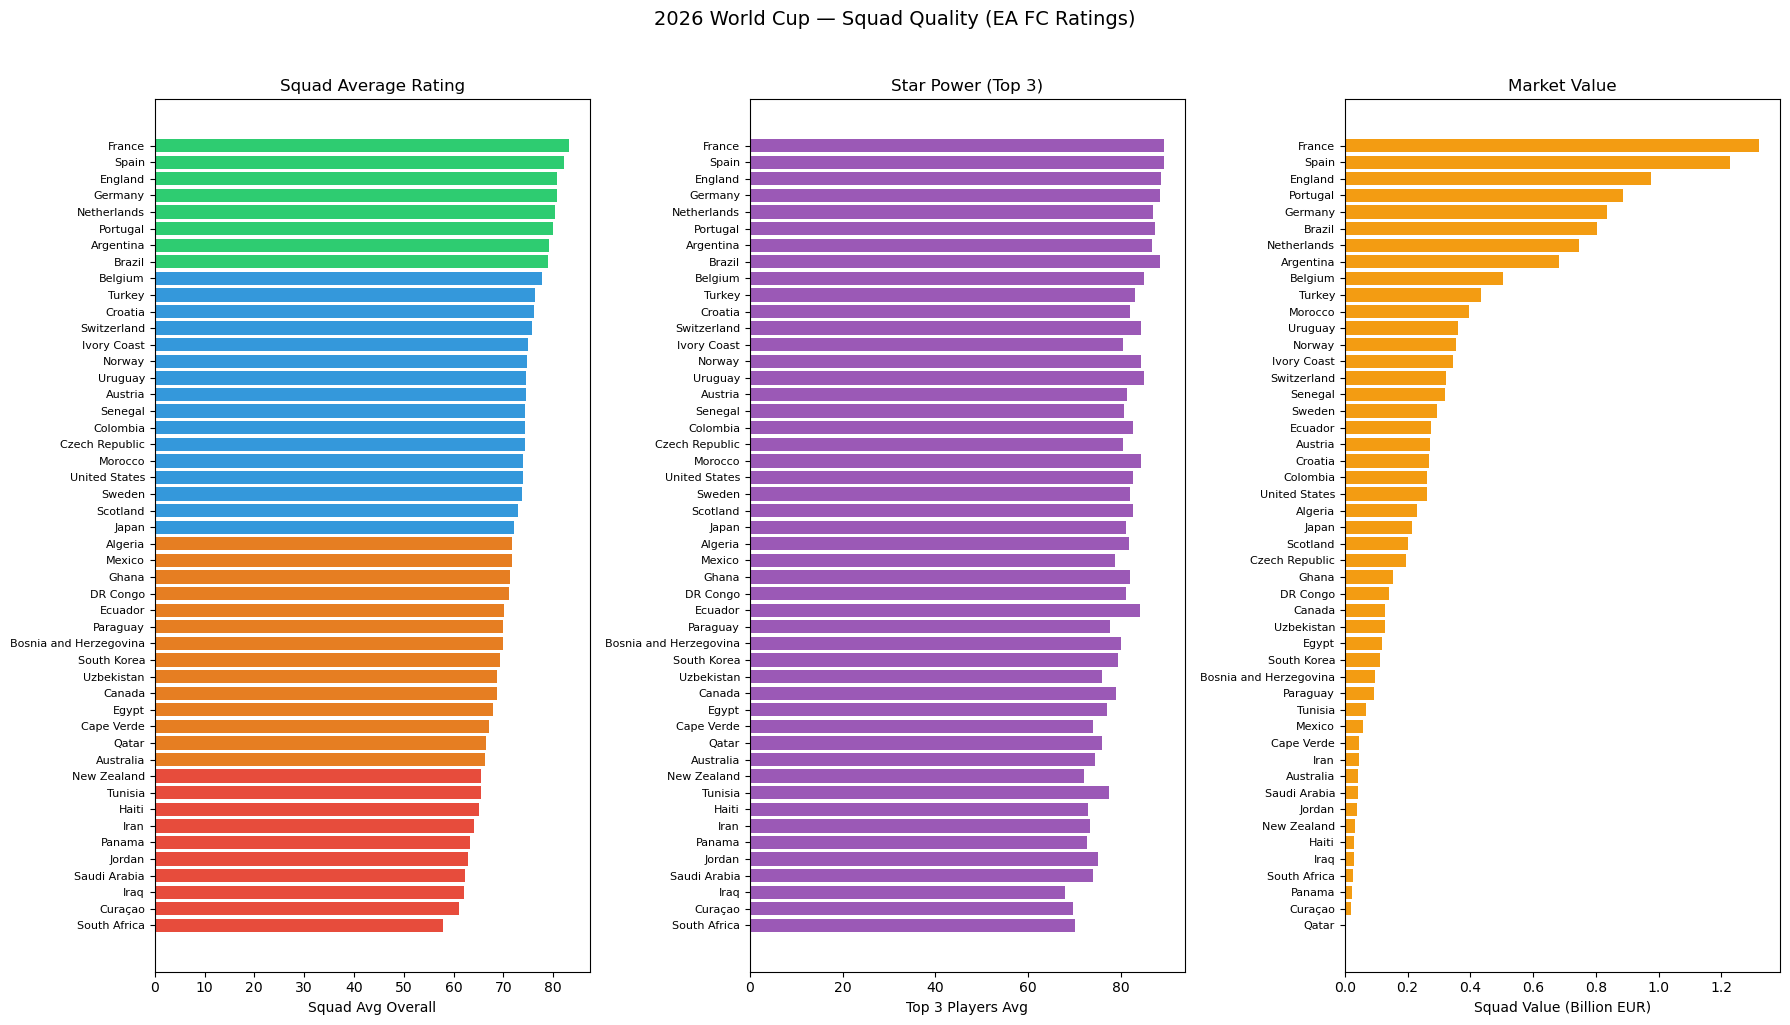

In [4]:
# 2026 team features — the 48 WC teams
t26 = team_features[team_features['year'] == 2026].sort_values('squad_avg_overall', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

# Squad avg overall
ax = axes[0]
colors = ['#2ecc71' if v >= 78 else '#3498db' if v >= 72 else '#e67e22' if v >= 66 else '#e74c3c' 
          for v in t26['squad_avg_overall']]
ax.barh(range(len(t26)), t26['squad_avg_overall'], color=colors)
ax.set_yticks(range(len(t26)))
ax.set_yticklabels(t26['team'], fontsize=8)
ax.set_xlabel('Squad Avg Overall')
ax.set_title('Squad Average Rating')
ax.invert_yaxis()

# Top 3 avg
ax = axes[1]
ax.barh(range(len(t26)), t26['squad_top3_avg'], color='#9b59b6')
ax.set_yticks(range(len(t26)))
ax.set_yticklabels(t26['team'], fontsize=8)
ax.set_xlabel('Top 3 Players Avg')
ax.set_title('Star Power (Top 3)')
ax.invert_yaxis()

# Squad value
ax = axes[2]
t26_val = t26.sort_values('squad_total_value', ascending=False)
ax.barh(range(len(t26_val)), t26_val['squad_total_value'] / 1e9, color='#f39c12')
ax.set_yticks(range(len(t26_val)))
ax.set_yticklabels(t26_val['team'], fontsize=8)
ax.set_xlabel('Squad Value (Billion EUR)')
ax.set_title('Market Value')
ax.invert_yaxis()

plt.suptitle('2026 World Cup — Squad Quality (EA FC Ratings)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

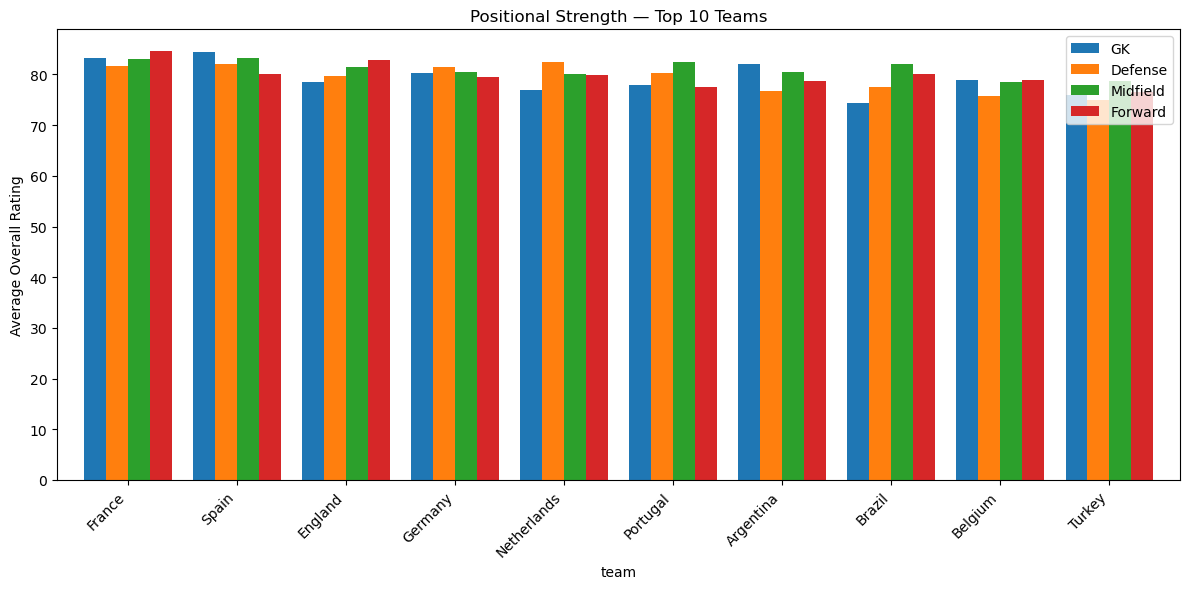

In [5]:
# Positional breakdown for top 10 teams
top10 = t26.head(10)
pos_cols = ['gk_avg', 'def_avg', 'mid_avg', 'fwd_avg']
pos_data = top10[['team'] + pos_cols].set_index('team')

fig, ax = plt.subplots(figsize=(12, 6))
pos_data.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Average Overall Rating')
ax.set_title('Positional Strength — Top 10 Teams')
ax.legend(['GK', 'Defense', 'Midfield', 'Forward'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Join Squad Features to Match Data

Map each match to team features by (team, year). Pre-2014 matches get NaN.

In [6]:
SQUAD_FEATURES = [
    'squad_avg_overall', 'squad_median_overall', 'squad_std_overall',
    'squad_top3_avg', 'squad_bottom5_avg',
    'gk_avg', 'def_avg', 'mid_avg', 'fwd_avg',
    'strongest_unit', 'weakest_unit',
    'squad_total_value', 'squad_avg_value',
    'squad_avg_age', 'squad_avg_potential_gap', 'squad_avg_caps',
    'team_pace', 'team_shooting', 'team_passing',
    'team_dribbling', 'team_defending', 'team_physic',
]

def join_squad_features(match_df, team_features):
    df = match_df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['match_year'] = df['date'].dt.year
    
    available_years = sorted(team_features['year'].unique())
    tf_indexed = team_features.set_index(['team', 'year'])
    
    def get_fifa_year(match_year):
        candidates = [y for y in available_years if y <= match_year]
        return max(candidates) if candidates else None
    
    df['fifa_year'] = df['match_year'].apply(get_fifa_year)
    
    # Vectorized join via merge
    home_tf = team_features.rename(columns={f: f'home_{f}' for f in SQUAD_FEATURES})
    home_tf = home_tf.rename(columns={'team': 'home_team', 'year': 'fifa_year'})
    away_tf = team_features.rename(columns={f: f'away_{f}' for f in SQUAD_FEATURES})
    away_tf = away_tf.rename(columns={'team': 'away_team', 'year': 'fifa_year'})
    
    home_cols = ['home_team', 'fifa_year'] + [f'home_{f}' for f in SQUAD_FEATURES]
    away_cols = ['away_team', 'fifa_year'] + [f'away_{f}' for f in SQUAD_FEATURES]
    
    df = df.merge(home_tf[home_cols], on=['home_team', 'fifa_year'], how='left')
    df = df.merge(away_tf[away_cols], on=['away_team', 'fifa_year'], how='left')
    
    # Diff features
    df['squad_avg_overall_diff'] = df['home_squad_avg_overall'] - df['away_squad_avg_overall']
    df['squad_top3_avg_diff'] = df['home_squad_top3_avg'] - df['away_squad_top3_avg']
    df['squad_value_diff'] = df['home_squad_total_value'] - df['away_squad_total_value']
    df['def_avg_diff'] = df['home_def_avg'] - df['away_def_avg']
    df['mid_avg_diff'] = df['home_mid_avg'] - df['away_mid_avg']
    df['fwd_avg_diff'] = df['home_fwd_avg'] - df['away_fwd_avg']
    df['team_shooting_diff'] = df['home_team_shooting'] - df['away_team_shooting']
    df['team_passing_diff'] = df['home_team_passing'] - df['away_team_passing']
    df['team_defending_diff'] = df['home_team_defending'] - df['away_team_defending']
    
    return df

train_aug = join_squad_features(train_df, team_features)
test_aug = join_squad_features(test_df, team_features)

# Coverage stats
train_has = train_aug['home_squad_avg_overall'].notna() & train_aug['away_squad_avg_overall'].notna()
test_has = test_aug['home_squad_avg_overall'].notna() & test_aug['away_squad_avg_overall'].notna()

print(f"Train coverage: {train_has.sum()}/{len(train_aug)} ({train_has.mean()*100:.1f}%)")
print(f"Test coverage: {test_has.sum()}/{len(test_aug)} ({test_has.mean()*100:.1f}%)")

# Coverage by year
train_aug['has_squad'] = train_has
cov_by_year = train_aug.groupby('match_year')['has_squad'].mean() * 100
print(f"\nTrain coverage by year:")
print(cov_by_year[cov_by_year.index >= 2010].round(1))

Train coverage: 2218/35304 (6.3%)
Test coverage: 995/3313 (30.0%)

Train coverage by year:
match_year
2010     0.0
2011     0.0
2012     0.0
2013     0.0
2014    30.9
2015    25.4
2016    35.7
2017    39.1
2018    35.9
2019    24.9
2020    60.7
2021    37.7
2022    38.2
Name: has_squad, dtype: float64


## 3. Correlation — Do squad features predict outcomes?

Before training any model, let's check: does `squad_avg_overall_diff` correlate with match outcome?

Matches with squad data — Train: 2218, Test: 995


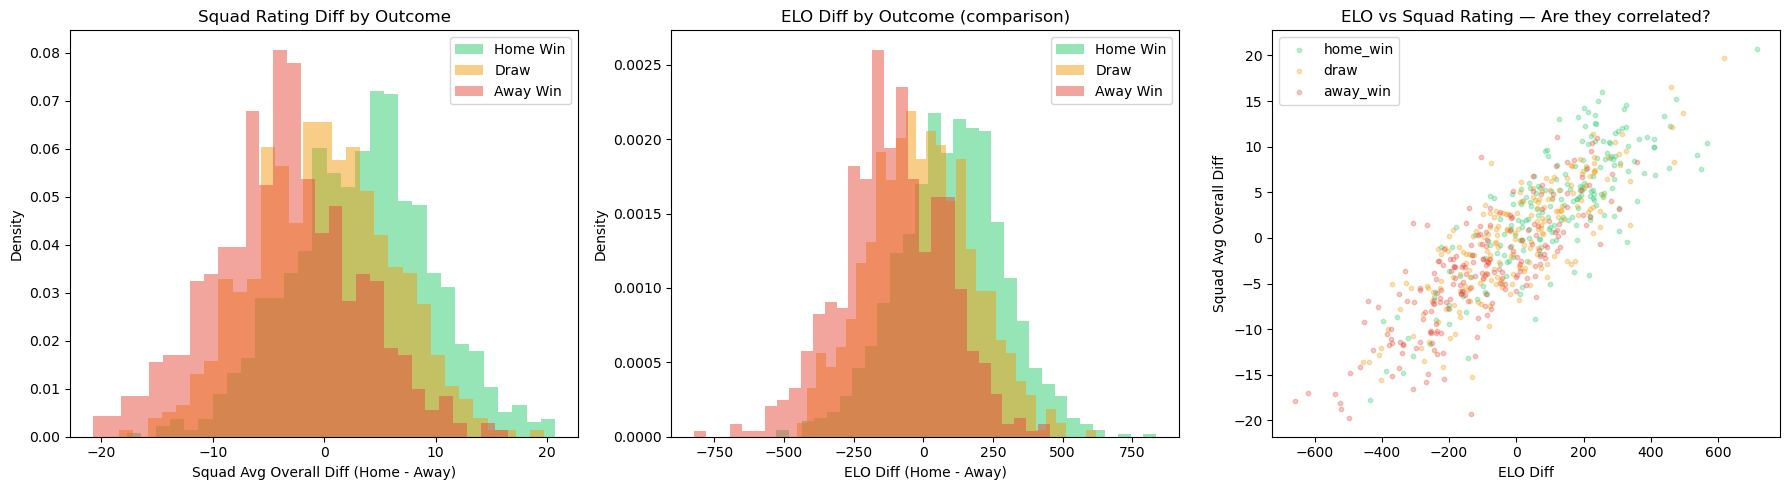


Correlation with outcome (home_win=1, draw=0.5, away_win=0):
  elo_diff                        r = 0.4197
  squad_avg_overall_diff          r = 0.4177
  squad_top3_avg_diff             r = 0.4123
  squad_value_diff                r = 0.3703
  fwd_avg_diff                    r = 0.4084
  def_avg_diff                    r = 0.4004

Correlation between elo_diff and squad_avg_overall_diff: 0.8327


In [7]:
# Only look at matches with squad data
train_sq = train_aug[train_has].copy()
test_sq = test_aug[test_has].copy()
print(f"Matches with squad data — Train: {len(train_sq)}, Test: {len(test_sq)}")

# Correlation between squad_avg_overall_diff and outcome
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of squad_avg_overall_diff by outcome
for outcome, color, label in [('home_win', '#2ecc71', 'Home Win'), 
                                ('draw', '#f39c12', 'Draw'),
                                ('away_win', '#e74c3c', 'Away Win')]:
    subset = train_sq[train_sq['outcome'] == outcome]['squad_avg_overall_diff']
    axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[0].set_xlabel('Squad Avg Overall Diff (Home - Away)')
axes[0].set_ylabel('Density')
axes[0].set_title('Squad Rating Diff by Outcome')
axes[0].legend()

# 2. Same for elo_diff — for comparison
for outcome, color, label in [('home_win', '#2ecc71', 'Home Win'), 
                                ('draw', '#f39c12', 'Draw'),
                                ('away_win', '#e74c3c', 'Away Win')]:
    subset = train_sq[train_sq['outcome'] == outcome]['elo_diff']
    axes[1].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[1].set_xlabel('ELO Diff (Home - Away)')
axes[1].set_ylabel('Density')
axes[1].set_title('ELO Diff by Outcome (comparison)')
axes[1].legend()

# 3. Scatter: squad_diff vs elo_diff, colored by outcome
outcome_colors = {'home_win': '#2ecc71', 'draw': '#f39c12', 'away_win': '#e74c3c'}
for outcome, color in outcome_colors.items():
    subset = train_sq[train_sq['outcome'] == outcome].sample(min(200, len(train_sq[train_sq['outcome']==outcome])))
    axes[2].scatter(subset['elo_diff'], subset['squad_avg_overall_diff'], 
                    c=color, alpha=0.3, s=10, label=outcome)
axes[2].set_xlabel('ELO Diff')
axes[2].set_ylabel('Squad Avg Overall Diff')
axes[2].set_title('ELO vs Squad Rating — Are they correlated?')
axes[2].legend()

plt.tight_layout()
plt.show()

# Correlation coefficients
print("\nCorrelation with outcome (home_win=1, draw=0.5, away_win=0):")
train_sq['outcome_num'] = train_sq['outcome'].map({'home_win': 1, 'draw': 0.5, 'away_win': 0})
corr_cols = ['elo_diff', 'squad_avg_overall_diff', 'squad_top3_avg_diff', 
             'squad_value_diff', 'fwd_avg_diff', 'def_avg_diff']
for col in corr_cols:
    r = train_sq[col].corr(train_sq['outcome_num'])
    print(f"  {col:30s}  r = {r:.4f}")

print(f"\nCorrelation between elo_diff and squad_avg_overall_diff: {train_sq['elo_diff'].corr(train_sq['squad_avg_overall_diff']):.4f}")

## 4. Model Training — Only EA Squad Features

Let's test the squad features standalone: can they predict match outcomes on their own?
Then combine with existing features using XGBoost's native NaN handling (all 35K matches).

In [8]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import joblib, json
from scipy.stats import poisson

# Existing 59 features (the baseline)
BASE_FEATURES = [
    "home_elo_before", "away_elo_before", "elo_diff",
    "home_win_rate_5", "home_avg_scored_5", "home_avg_conceded_5",
    "home_pts_per_match_5", "home_matches_played_5",
    "home_win_rate_10", "home_avg_scored_10", "home_avg_conceded_10",
    "home_pts_per_match_10", "home_matches_played_10",
    "away_win_rate_5", "away_avg_scored_5", "away_avg_conceded_5",
    "away_pts_per_match_5", "away_matches_played_5",
    "away_win_rate_10", "away_avg_scored_10", "away_avg_conceded_10",
    "away_pts_per_match_10", "away_matches_played_10",
    "h2h_home_win_rate", "h2h_home_avg_scored", "h2h_home_avg_conceded",
    "h2h_total_meetings", "h2h_recent_win_rate",
    "neutral.1", "tournament_importance",
    "home_conf_UEFA", "home_conf_CAF", "home_conf_AFC",
    "home_conf_CONCACAF", "home_conf_CONMEBOL", "home_conf_OFC", "home_conf_UNKNOWN",
    "away_conf_UEFA", "away_conf_CAF", "away_conf_AFC",
    "away_conf_CONCACAF", "away_conf_CONMEBOL", "away_conf_OFC", "away_conf_UNKNOWN",
    "same_confederation",
    "elo_diff_sq", "home_form_momentum", "away_form_momentum",
    "home_goal_diff_form", "away_goal_diff_form", "net_goal_diff", "h2h_confidence",
    "dc_home_win_prob", "dc_draw_prob", "dc_away_win_prob",
    "dc_lambda", "dc_mu", "dc_total_goals", "dc_goal_diff",
]

# New EA squad features
HOME_SQUAD = [f'home_{f}' for f in SQUAD_FEATURES]
AWAY_SQUAD = [f'away_{f}' for f in SQUAD_FEATURES]
DIFF_FEATURES = [
    'squad_avg_overall_diff', 'squad_top3_avg_diff', 'squad_value_diff',
    'def_avg_diff', 'mid_avg_diff', 'fwd_avg_diff',
    'team_shooting_diff', 'team_passing_diff', 'team_defending_diff',
]
EA_ONLY = HOME_SQUAD + AWAY_SQUAD + DIFF_FEATURES

# Labels
le = LabelEncoder()
y_train_all = le.fit_transform(train_aug['outcome'].values)
y_test_all = le.transform(test_aug['outcome'].values)

# For squad-only models, use only rows with squad data
y_train_sq = le.transform(train_sq['outcome'].values)
y_test_sq = le.transform(test_sq['outcome'].values)

classes = np.unique(y_train_all)
cw_all = dict(zip(classes, compute_class_weight("balanced", classes=classes, y=y_train_all)))
cw_sq = dict(zip(classes, compute_class_weight("balanced", classes=classes, y=y_train_sq)))

# DC model for blending
dc_bundle = joblib.load(MODELS_DIR / "dc_model.pkl")
attack_params = dc_bundle["attack"]
defense_params = dc_bundle["defense"]
team_idx_dc = dc_bundle["team_idx"]
with open(MODELS_DIR / "dc_params.json") as f:
    dp = json.load(f)
home_adv_dc, rho_dc = dp["home_adv"], dp["rho"]

def dc_probs(home, away, neutral):
    if home not in team_idx_dc or away not in team_idx_dc:
        return np.array([0.30, 0.25, 0.45])
    goals = np.arange(11)
    hi, ai = team_idx_dc[home], team_idx_dc[away]
    ha = home_adv_dc if not neutral else 0.0
    lam = np.exp(attack_params[hi] + defense_params[ai] + ha)
    mu = np.exp(attack_params[ai] + defense_params[hi])
    sm = np.outer(poisson.pmf(goals, lam), poisson.pmf(goals, mu))
    sm[0,0] *= max(1-lam*mu*rho_dc, 1e-10)
    sm[0,1] *= max(1+lam*rho_dc, 1e-10)
    sm[1,0] *= max(1+mu*rho_dc, 1e-10)
    sm[1,1] *= max(1-rho_dc, 1e-10)
    hw = float(np.sum(sm * (goals[:,None] > goals[None,:])))
    dr = float(np.sum(sm * (goals[:,None] == goals[None,:])))
    aw = max(0, 1.0-hw-dr)
    t = hw+dr+aw
    return np.array([aw/t, dr/t, hw/t])

dc_test_all = np.array([dc_probs(r['home_team'], r['away_team'], 
    bool(r.get('neutral', r.get('neutral.1', True)))) for _, r in test_aug.iterrows()])
dc_test_sq = np.array([dc_probs(r['home_team'], r['away_team'],
    bool(r.get('neutral', r.get('neutral.1', True)))) for _, r in test_sq.iterrows()])

print("Setup done!")

Setup done!


In [9]:
results = []

def evaluate(name, y_true, y_proba, dc_proba=None, w_dc=1):
    """Evaluate and optionally blend with DC."""
    if dc_proba is not None:
        proba = (5 * y_proba + w_dc * dc_proba) / (5 + w_dc)
    else:
        proba = y_proba
    ll = log_loss(y_true, proba)
    acc = accuracy_score(y_true, np.argmax(proba, axis=1))
    f1 = f1_score(y_true, np.argmax(proba, axis=1), average='macro')
    results.append((name, ll, acc, f1, len(y_true)))
    print(f"  {name:60s}  ll={ll:.4f}  acc={acc:.4f}  n={len(y_true)}")
    return ll

XGB_P = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
             subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)

print("="*80)
print("MODEL COMPARISONS")
print("="*80)

MODEL COMPARISONS


## 5. Model A — EA Squad Features ONLY

Can EA ratings alone predict match outcomes? Training on the ~2K matches where both teams have squad data.

In [10]:
# ── Model A: EA-only features on squad-covered subset ──
print("="*70)
print("MODEL A: EA Squad Features ONLY (squad-covered matches)")
print("="*70)

# Feature sets to test
EA_DIFF_ONLY = DIFF_FEATURES  # 9 diff features
EA_ALL = HOME_SQUAD + AWAY_SQUAD + DIFF_FEATURES  # 53 features

# A1: Just the 9 diff features
print("\n[A1] EA diff features only (9 features)")
X_tr_a1 = train_sq[EA_DIFF_ONLY].fillna(0).values
X_te_a1 = test_sq[EA_DIFF_ONLY].fillna(0).values
sc_a1 = StandardScaler()
X_tr_a1 = sc_a1.fit_transform(X_tr_a1)
X_te_a1 = sc_a1.transform(X_te_a1)

xgb_a1 = CalibratedClassifierCV(
    xgb.XGBClassifier(**XGB_P, eval_metric="mlogloss", random_state=42, verbosity=0),
    method="isotonic", cv=5)
xgb_a1.fit(X_tr_a1, y_train_sq)
p_a1 = xgb_a1.predict_proba(X_te_a1)
evaluate("A1: EA diff only (9 feat)", y_test_sq, p_a1)
evaluate("A1: EA diff only + DC blend", y_test_sq, p_a1, dc_test_sq)

# A2: All 53 EA features
print("\n[A2] All EA features (53 features)")
X_tr_a2 = train_sq[EA_ALL].fillna(0).values
X_te_a2 = test_sq[EA_ALL].fillna(0).values
sc_a2 = StandardScaler()
X_tr_a2 = sc_a2.fit_transform(X_tr_a2)
X_te_a2 = sc_a2.transform(X_te_a2)

xgb_a2 = CalibratedClassifierCV(
    xgb.XGBClassifier(**XGB_P, eval_metric="mlogloss", random_state=42, verbosity=0),
    method="isotonic", cv=5)
xgb_a2.fit(X_tr_a2, y_train_sq)
p_a2 = xgb_a2.predict_proba(X_te_a2)
evaluate("A2: All EA features (53 feat)", y_test_sq, p_a2)
evaluate("A2: All EA features + DC blend", y_test_sq, p_a2, dc_test_sq)

# A3: Logistic Regression on EA diff (sanity check — is the signal linear?)
print("\n[A3] Logistic Regression on EA diff (linear signal test)")
lr_a3 = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", multi_class="multinomial", random_state=42)
lr_a3.fit(X_tr_a1, y_train_sq)
p_a3 = lr_a3.predict_proba(X_te_a1)
evaluate("A3: LR on EA diff (9 feat)", y_test_sq, p_a3)
evaluate("A3: LR on EA diff + DC blend", y_test_sq, p_a3, dc_test_sq)

MODEL A: EA Squad Features ONLY (squad-covered matches)

[A1] EA diff features only (9 features)
  A1: EA diff only (9 feat)                                     ll=0.9707  acc=0.5457  n=995
  A1: EA diff only + DC blend                                   ll=0.9452  acc=0.5538  n=995

[A2] All EA features (53 features)
  A2: All EA features (53 feat)                                 ll=1.0343  acc=0.5226  n=995
  A2: All EA features + DC blend                                ll=0.9425  acc=0.5437  n=995

[A3] Logistic Regression on EA diff (linear signal test)
  A3: LR on EA diff (9 feat)                                    ll=0.9444  acc=0.5407  n=995
  A3: LR on EA diff + DC blend                                  ll=0.9230  acc=0.5558  n=995


0.923021205059176

## 6. Model B — Baseline (59 features, no EA) on same subset

Compare apples-to-apples: how does the current 59-feature model perform on the same squad-covered test set?

In [11]:
# ── Model B: Baseline 59 features on squad-covered subset ──
print("="*70)
print("MODEL B: BASELINE (59 features, no EA)")
print("="*70)

# B1: Train on ALL 35K, test on squad-covered subset
print("\n[B1] Baseline: 59 feat, trained on ALL 35K, tested on squad-covered subset")
X_tr_b1 = train_aug[BASE_FEATURES].values
X_te_b1 = test_sq[BASE_FEATURES].values
sc_b1 = StandardScaler()
X_tr_b1 = sc_b1.fit_transform(X_tr_b1)
X_te_b1 = sc_b1.transform(X_te_b1)

ens_b1 = VotingClassifier(
    estimators=[
        ("xgb", CalibratedClassifierCV(xgb.XGBClassifier(**XGB_P, eval_metric="mlogloss", random_state=42, verbosity=0), method="isotonic", cv=5)),
        ("rf", CalibratedClassifierCV(RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1), method="isotonic", cv=5)),
    ], voting="soft", weights=[4, 1], n_jobs=-1)
ens_b1.fit(X_tr_b1, y_train_all)
p_b1 = ens_b1.predict_proba(X_te_b1)
evaluate("B1: Baseline 59 feat (35K train)", y_test_sq, p_b1)
evaluate("B1: Baseline 59 feat + DC blend", y_test_sq, p_b1, dc_test_sq)

# B2: Train on squad-covered subset only (apples-to-apples with Model A)
print("\n[B2] Baseline: 59 feat, trained on squad-covered only (~2K)")
X_tr_b2 = train_sq[BASE_FEATURES].values
X_te_b2 = test_sq[BASE_FEATURES].values
sc_b2 = StandardScaler()
X_tr_b2 = sc_b2.fit_transform(X_tr_b2)
X_te_b2 = sc_b2.transform(X_te_b2)

xgb_b2 = CalibratedClassifierCV(
    xgb.XGBClassifier(**XGB_P, eval_metric="mlogloss", random_state=42, verbosity=0),
    method="isotonic", cv=5)
xgb_b2.fit(X_tr_b2, y_train_sq)
p_b2 = xgb_b2.predict_proba(X_te_b2)
evaluate("B2: Baseline 59 feat (2K train)", y_test_sq, p_b2)
evaluate("B2: Baseline 59 feat (2K) + DC", y_test_sq, p_b2, dc_test_sq)

MODEL B: BASELINE (59 features, no EA)

[B1] Baseline: 59 feat, trained on ALL 35K, tested on squad-covered subset
  B1: Baseline 59 feat (35K train)                              ll=0.9142  acc=0.5759  n=995
  B1: Baseline 59 feat + DC blend                               ll=0.9026  acc=0.5809  n=995

[B2] Baseline: 59 feat, trained on squad-covered only (~2K)
  B2: Baseline 59 feat (2K train)                               ll=0.9666  acc=0.5618  n=995
  B2: Baseline 59 feat (2K) + DC                                ll=0.9176  acc=0.5719  n=995


0.9175694955238671

## 7. Model C — Combined (Base + EA) with XGBoost NaN handling

XGBoost can handle NaN natively — it learns the optimal split direction for missing values.
This lets us use ALL 35K training matches: pre-2014 matches have NaN for squad features, XGBoost treats them as "unknown" (not "zero").

In [12]:
# ── Model C: Combined base + EA, XGBoost native NaN ──
print("="*70)
print("MODEL C: COMBINED (Base + EA) — XGBoost NaN handling")
print("="*70)

ALL_FEATURES = BASE_FEATURES + [f'home_{f}' for f in SQUAD_FEATURES] + [f'away_{f}' for f in SQUAD_FEATURES] + DIFF_FEATURES

# C1: XGBoost only, all 35K, NaN kept as-is (XGBoost handles it)
print("\n[C1] XGB + all features (112 feat), 35K train, NaN native")
X_tr_c1 = train_aug[ALL_FEATURES].values  # Keep NaN!
X_te_c1 = test_aug[ALL_FEATURES].values

# XGBoost handles NaN natively — no scaler needed for XGB
xgb_c1 = CalibratedClassifierCV(
    xgb.XGBClassifier(**XGB_P, eval_metric="mlogloss", random_state=42, verbosity=0),
    method="isotonic", cv=5)
xgb_c1.fit(X_tr_c1, y_train_all)
p_c1 = xgb_c1.predict_proba(X_te_c1)

# DC probs for full test
dc_test_full = np.array([dc_probs(r['home_team'], r['away_team'], 
    bool(r.get('neutral', r.get('neutral.1', True)))) for _, r in test_aug.iterrows()])

evaluate("C1: XGB 112 feat, 35K, NaN native", y_test_all, p_c1)
evaluate("C1: XGB 112 feat + DC blend", y_test_all, p_c1, dc_test_full)

# C2: HistGradientBoosting (also handles NaN natively) + RF fallback
print("\n[C2] HistGBT + all features (112 feat), 35K train")
hgb_c2 = CalibratedClassifierCV(
    HistGradientBoostingClassifier(max_iter=300, max_depth=5, learning_rate=0.05, random_state=42),
    method="isotonic", cv=5)
hgb_c2.fit(X_tr_c1, y_train_all)
p_c2 = hgb_c2.predict_proba(X_te_c1)
evaluate("C2: HistGBT 112 feat, 35K, NaN native", y_test_all, p_c2)
evaluate("C2: HistGBT 112 feat + DC blend", y_test_all, p_c2, dc_test_full)

# C3: Blend XGB + HistGBT (both handle NaN)
print("\n[C3] Blend: XGB×4 + HistGBT×1")
p_c3 = (4*p_c1 + 1*p_c2) / 5
evaluate("C3: XGB×4 + HistGBT×1, 112 feat", y_test_all, p_c3)
evaluate("C3: XGB×4 + HistGBT×1 + DC", y_test_all, p_c3, dc_test_full)

# C4: Just diff features + base (68 feat) — less overfitting risk
print("\n[C4] XGB + base + diff only (68 feat), 35K train")
COMBINED_LEAN = BASE_FEATURES + DIFF_FEATURES
X_tr_c4 = train_aug[COMBINED_LEAN].values
X_te_c4 = test_aug[COMBINED_LEAN].values

xgb_c4 = CalibratedClassifierCV(
    xgb.XGBClassifier(**XGB_P, eval_metric="mlogloss", random_state=42, verbosity=0),
    method="isotonic", cv=5)
xgb_c4.fit(X_tr_c4, y_train_all)
p_c4 = xgb_c4.predict_proba(X_te_c4)
evaluate("C4: XGB 68 feat (base+diff), 35K", y_test_all, p_c4)
evaluate("C4: XGB 68 feat + DC blend", y_test_all, p_c4, dc_test_full)

MODEL C: COMBINED (Base + EA) — XGBoost NaN handling

[C1] XGB + all features (112 feat), 35K train, NaN native
  C1: XGB 112 feat, 35K, NaN native                             ll=0.8228  acc=0.6269  n=3313
  C1: XGB 112 feat + DC blend                                   ll=0.8109  acc=0.6299  n=3313

[C2] HistGBT + all features (112 feat), 35K train
  C2: HistGBT 112 feat, 35K, NaN native                         ll=0.8242  acc=0.6266  n=3313
  C2: HistGBT 112 feat + DC blend                               ll=0.8126  acc=0.6293  n=3313

[C3] Blend: XGB×4 + HistGBT×1
  C3: XGB×4 + HistGBT×1, 112 feat                               ll=0.8223  acc=0.6287  n=3313
  C3: XGB×4 + HistGBT×1 + DC                                    ll=0.8107  acc=0.6299  n=3313

[C4] XGB + base + diff only (68 feat), 35K train
  C4: XGB 68 feat (base+diff), 35K                              ll=0.8243  acc=0.6248  n=3313
  C4: XGB 68 feat + DC blend                                    ll=0.8119  acc=0.6312  n=3313


0.8119421018619043

## 8. Results Summary & Feature Importance

In [13]:
# ── Results Table ──
print("="*80)
print("ALL RESULTS (sorted by log loss — lower is better)")
print("="*80)
print(f"  {'Model':55s}  {'LogLoss':>8s}  {'Acc':>7s}  {'N':>5s}")
print("-"*85)
for name, ll, acc, f1, n in sorted(results, key=lambda x: x[1]):
    print(f"  {name:55s}  {ll:8.4f}  {acc:7.4f}  {n:5d}")

# Highlight key comparisons
print("\n" + "="*80)
print("KEY COMPARISONS")
print("="*80)
ea_only = [r for r in results if r[0].startswith("A")]
baselines = [r for r in results if r[0].startswith("B")]
combined = [r for r in results if r[0].startswith("C")]

best_ea = min(ea_only, key=lambda x: x[1]) if ea_only else None
best_base = min(baselines, key=lambda x: x[1]) if baselines else None
best_combined = min(combined, key=lambda x: x[1]) if combined else None

if best_ea:
    print(f"  Best EA-only:    {best_ea[0]:45s}  ll={best_ea[1]:.4f}")
if best_base:
    print(f"  Best Baseline:   {best_base[0]:45s}  ll={best_base[1]:.4f}")
if best_combined:
    print(f"  Best Combined:   {best_combined[0]:45s}  ll={best_combined[1]:.4f}")

ALL RESULTS (sorted by log loss — lower is better)
  Model                                                     LogLoss      Acc      N
-------------------------------------------------------------------------------------
  C3: XGB×4 + HistGBT×1 + DC                                 0.8107   0.6299   3313
  C1: XGB 112 feat + DC blend                                0.8109   0.6299   3313
  C4: XGB 68 feat + DC blend                                 0.8119   0.6312   3313
  C2: HistGBT 112 feat + DC blend                            0.8126   0.6293   3313
  C3: XGB×4 + HistGBT×1, 112 feat                            0.8223   0.6287   3313
  C1: XGB 112 feat, 35K, NaN native                          0.8228   0.6269   3313
  C2: HistGBT 112 feat, 35K, NaN native                      0.8242   0.6266   3313
  C4: XGB 68 feat (base+diff), 35K                           0.8243   0.6248   3313
  B1: Baseline 59 feat + DC blend                            0.9026   0.5809    995
  B1: Baseline 59 feat 

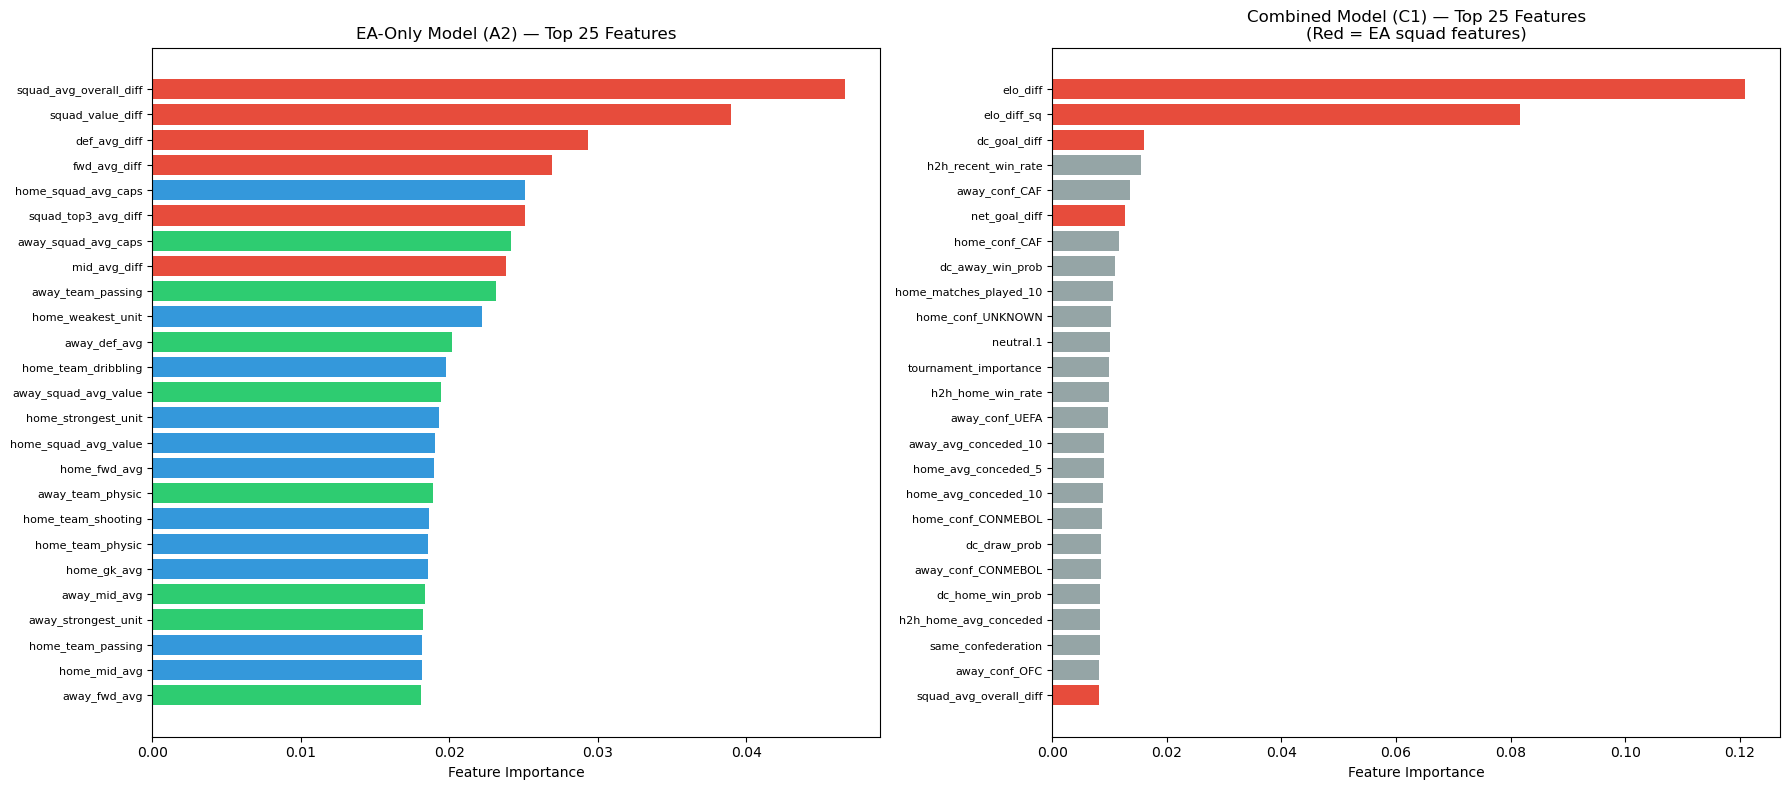

In [14]:
# ── Feature Importance: EA-only model ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# A2: All EA features importance
ax = axes[0]
xgb_inner_a2 = xgb_a2.calibrated_classifiers_[0].estimator
if hasattr(xgb_inner_a2, 'feature_importances_'):
    imp_a2 = xgb_inner_a2.feature_importances_
    feat_imp_a2 = sorted(zip(EA_ALL, imp_a2), key=lambda x: -x[1])[:25]
    names, vals = zip(*feat_imp_a2)
    colors = ['#e74c3c' if 'diff' in n else '#3498db' if 'home' in n else '#2ecc71' for n in names]
    ax.barh(range(len(names)), vals, color=colors)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('Feature Importance')
    ax.set_title('EA-Only Model (A2) — Top 25 Features')
    ax.invert_yaxis()

# C1: Combined model importance
ax = axes[1]
xgb_inner_c1 = xgb_c1.calibrated_classifiers_[0].estimator
if hasattr(xgb_inner_c1, 'feature_importances_'):
    imp_c1 = xgb_inner_c1.feature_importances_
    feat_imp_c1 = sorted(zip(ALL_FEATURES, imp_c1), key=lambda x: -x[1])[:25]
    names, vals = zip(*feat_imp_c1)
    colors = ['#e74c3c' if any(k in n for k in ['diff','squad','def_avg','mid_avg','fwd_avg','team_shooting','team_passing','team_defending']) 
              else '#95a5a6' for n in names]
    ax.barh(range(len(names)), vals, color=colors)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Combined Model (C1) — Top 25 Features\n(Red = EA squad features)')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Sanity Check — 2026 WC Predictions

What does the EA-only model think about 2026 WC matchups? Does it fix the confederation bias?

In [15]:
# ── Sanity check: predict some 2026 WC matchups ──
print("="*70)
print("2026 WC SANITY CHECK — EA-only model predictions")
print("="*70)

t26 = team_features[team_features['year'] == 2026].set_index('team')
matchups = [
    ("Brazil", "Mexico", True),
    ("France", "Norway", True),
    ("Portugal", "Mexico", True),
    ("Spain", "Japan", True),
    ("Argentina", "Saudi Arabia", True),
    ("Germany", "South Korea", True),
    ("England", "United States", True),
    ("Belgium", "Morocco", True),
]

print(f"\n  {'Home':15s} vs {'Away':15s}  {'H Win':>7s}  {'Draw':>7s}  {'A Win':>7s}  | {'DC H':>6s}  {'DC D':>6s}  {'DC A':>6s}")
print("-"*85)

for home, away, neutral in matchups:
    if home not in t26.index or away not in t26.index:
        print(f"  {home:15s} vs {away:15s}  — missing squad data")
        continue
    
    # Build EA feature vector
    feat_row = {}
    for f in SQUAD_FEATURES:
        feat_row[f'home_{f}'] = t26.loc[home, f]
        feat_row[f'away_{f}'] = t26.loc[away, f]
    
    feat_row['squad_avg_overall_diff'] = feat_row['home_squad_avg_overall'] - feat_row['away_squad_avg_overall']
    feat_row['squad_top3_avg_diff'] = feat_row['home_squad_top3_avg'] - feat_row['away_squad_top3_avg']
    feat_row['squad_value_diff'] = feat_row['home_squad_total_value'] - feat_row['away_squad_total_value']
    feat_row['def_avg_diff'] = feat_row['home_def_avg'] - feat_row['away_def_avg']
    feat_row['mid_avg_diff'] = feat_row['home_mid_avg'] - feat_row['away_mid_avg']
    feat_row['fwd_avg_diff'] = feat_row['home_fwd_avg'] - feat_row['away_fwd_avg']
    feat_row['team_shooting_diff'] = feat_row['home_team_shooting'] - feat_row['away_team_shooting']
    feat_row['team_passing_diff'] = feat_row['home_team_passing'] - feat_row['away_team_passing']
    feat_row['team_defending_diff'] = feat_row['home_team_defending'] - feat_row['away_team_defending']
    
    x = np.array([[feat_row[f] for f in EA_ALL]])
    x_scaled = sc_a2.transform(x)
    p = xgb_a2.predict_proba(x_scaled)[0]
    
    # DC comparison
    dc_p = dc_probs(home, away, neutral)
    
    # Classes: le.classes_ = ['away_win', 'draw', 'home_win']
    print(f"  {home:15s} vs {away:15s}  {p[2]:7.1%}  {p[1]:7.1%}  {p[0]:7.1%}  | {dc_p[2]:6.1%}  {dc_p[1]:6.1%}  {dc_p[0]:6.1%}")

print("\n  Left: EA-only model | Right: Dixon-Coles model")
print("  If EA model gives Portugal > Mexico, the confederation bias fix is working!")

2026 WC SANITY CHECK — EA-only model predictions

  Home            vs Away               H Win     Draw    A Win  |   DC H    DC D    DC A
-------------------------------------------------------------------------------------
  Brazil          vs Mexico             62.0%    26.8%    11.2%  |  12.1%   30.5%   57.5%
  France          vs Norway             60.6%    30.2%     9.2%  |  42.7%   29.1%   28.2%
  Portugal        vs Mexico             62.6%    24.1%    13.3%  |  15.9%   31.7%   52.4%
  Spain           vs Japan              65.7%    26.3%     8.0%  |  27.5%   29.4%   43.1%
  Argentina       vs Saudi Arabia       80.7%    19.3%     0.0%  |  41.9%   36.9%   21.2%
  Germany         vs South Korea        67.0%    23.6%     9.4%  |  22.1%   28.3%   49.6%
  England         vs United States      65.9%    28.1%     5.9%  |  21.8%   44.2%   34.0%
  Belgium         vs Morocco            57.4%    26.0%    16.6%  |  11.7%   26.6%   61.7%

  Left: EA-only model | Right: Dixon-Coles model
  If